In [1]:
import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv('/content/messy_football_players_8000.csv')
df1=df.copy()
df


,age,position,finishing,shot_power,heading_accuracy,crossing,short_passing,long_passing,through_ball,dribbling,...,stamina,offensive_awareness,composure,reactions,gk_diving,gk_handling,gk_kicking,gk_reflexes,gk_positioning,overall_rating
0,29.0,CM,NaN,91.0,NaN,75.0,99.0,86.0,92.0,79.0,...,91.0,NaN,75.0,87.0,13.0,8.0,15.0,16.0,4.0,91
1,30.0,RB,NaN,49.0,NaN,63.0,36.0,49.0,NaN,36.0,...,42.0,61.0,57.0,39.0,2.0,8.0,6.0,7.0,4.0,59
2,16.0,CB,36.0,54.0,65.0,55.0,58.0,57.0,65.0,53.0,...,73.0,66.0,48.0,59.0,11.0,10.0,7.0,12.0,9.0,64
3,29.0,LM,NaN,72.0,59.0,72.0,64.0,77.0,63.0,70.0,...,49.0,NaN,62.0,64.0,4.0,8.0,3.0,11.0,7.0,61
4,21.0,LW,70.0,60.0,59.0,59.0,66.0,53.0,NaN,60.0,...,39.0,82.0,61.0,43.0,4.0,2.0,10.0,4.0,3.0,60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,21.0,CAM,54.0,80.0,74.0,61.0,72.0,71.0,73.0,53.0,...,52.0,62.0,52.0,55.0,16.0,14.0,13.0,16.0,11.0,71
7996,32.0,RW,66.0,63.0,59.0,53.0,72.0,57.0,68.0,55.0,...,56.0,NaN,54.0,44.0,9.0,12.0,13.0,11.0,15.0,59
7997,35.0,CDM,39.0,75.0,84.0,82.0,78.0,81.0,68.0,77.0,...,76.0,67.0,79.0,86.0,14.0,3.0,9.0,1.0,10.0,91
7998,25.0,CB,13.0,50.0,36.0,54.0,43.0,39.0,42.0,58.0,...,58.0,38.0,45.0,57.0,7.0,14.0,13.0,11.0,3.0,54


In [3]:
df.head()

,age,position,finishing,shot_power,heading_accuracy,crossing,short_passing,long_passing,through_ball,dribbling,...,stamina,offensive_awareness,composure,reactions,gk_diving,gk_handling,gk_kicking,gk_reflexes,gk_positioning,overall_rating
0,29.0,CM,NaN,91.0,NaN,75.0,99.0,86.0,92.0,79.0,...,91.0,NaN,75.0,87.0,13.0,8.0,15.0,16.0,4.0,91
1,30.0,RB,NaN,49.0,NaN,63.0,36.0,49.0,NaN,36.0,...,42.0,61.0,57.0,39.0,2.0,8.0,6.0,7.0,4.0,59
2,16.0,CB,36.0,54.0,65.0,55.0,58.0,57.0,65.0,53.0,...,73.0,66.0,48.0,59.0,11.0,10.0,7.0,12.0,9.0,64
3,29.0,LM,NaN,72.0,59.0,72.0,64.0,77.0,63.0,70.0,...,49.0,NaN,62.0,64.0,4.0,8.0,3.0,11.0,7.0,61
4,21.0,LW,70.0,60.0,59.0,59.0,66.0,53.0,NaN,60.0,...,39.0,82.0,61.0,43.0,4.0,2.0,10.0,4.0,3.0,60


In [4]:
df.dtypes

,0
age,object
position,object
finishing,object
shot_power,object
heading_accuracy,object
crossing,float64
short_passing,float64
long_passing,float64
through_ball,float64
dribbling,float64


In [5]:
for col in df.loc[:, ['age', 'finishing', 'shot_power', 'heading_accuracy']]:
  df[col] = pd.to_numeric(df[col], errors="coerce")
df.dtypes


,0
age,float64
position,object
finishing,float64
shot_power,float64
heading_accuracy,float64
crossing,float64
short_passing,float64
long_passing,float64
through_ball,float64
dribbling,float64


In [6]:
#age cleaning
df['age'].isna().sum()

np.int64(541)

In [7]:
np.sort(df['age'].unique())

array([-50.,  -1.,  16.,  17.,  18.,  19.,  20.,  21.,  22.,  23.,  24.,
        25.,  26.,  27.,  28.,  29.,  30.,  31.,  32.,  33.,  34.,  35.,
        36.,  37.,  38.,  39.,  40.,  99., 999.,  nan])

In [8]:
df['age'].value_counts()

,count
age,
25.0,651
24.0,642
23.0,636
26.0,621
22.0,570
27.0,538
21.0,497
28.0,472
20.0,392


In [9]:
df['age'] =df['age'].fillna(df['age'].median())

In [10]:
df = df[(df['age'] > 14) & (df['age'] < 41)]
df
# age cleaning completed

,age,position,finishing,shot_power,heading_accuracy,crossing,short_passing,long_passing,through_ball,dribbling,...,stamina,offensive_awareness,composure,reactions,gk_diving,gk_handling,gk_kicking,gk_reflexes,gk_positioning,overall_rating
0,29.0,CM,NaN,91.0,NaN,75.0,99.0,86.0,92.0,79.0,...,91.0,NaN,75.0,87.0,13.0,8.0,15.0,16.0,4.0,91
1,30.0,RB,NaN,49.0,NaN,63.0,36.0,49.0,NaN,36.0,...,42.0,61.0,57.0,39.0,2.0,8.0,6.0,7.0,4.0,59
2,16.0,CB,36.0,54.0,65.0,55.0,58.0,57.0,65.0,53.0,...,73.0,66.0,48.0,59.0,11.0,10.0,7.0,12.0,9.0,64
3,29.0,LM,NaN,72.0,59.0,72.0,64.0,77.0,63.0,70.0,...,49.0,NaN,62.0,64.0,4.0,8.0,3.0,11.0,7.0,61
4,21.0,LW,70.0,60.0,59.0,59.0,66.0,53.0,NaN,60.0,...,39.0,82.0,61.0,43.0,4.0,2.0,10.0,4.0,3.0,60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,21.0,CAM,54.0,80.0,74.0,61.0,72.0,71.0,73.0,53.0,...,52.0,62.0,52.0,55.0,16.0,14.0,13.0,16.0,11.0,71
7996,32.0,RW,66.0,63.0,59.0,53.0,72.0,57.0,68.0,55.0,...,56.0,NaN,54.0,44.0,9.0,12.0,13.0,11.0,15.0,59
7997,35.0,CDM,39.0,75.0,84.0,82.0,78.0,81.0,68.0,77.0,...,76.0,67.0,79.0,86.0,14.0,3.0,9.0,1.0,10.0,91
7998,25.0,CB,13.0,50.0,36.0,54.0,43.0,39.0,42.0,58.0,...,58.0,38.0,45.0,57.0,7.0,14.0,13.0,11.0,3.0,54


In [11]:
# position_cleaning
df['position'].isna().sum()

np.int64(0)

In [12]:
df['position'].unique()

array(['CM', 'RB', 'CB', 'LM', 'LW', 'ST', 'LB', 'RM', 'CF', 'RW', 'CAM',
       'CDM', 'GK'], dtype=object)

In [13]:
df

,age,position,finishing,shot_power,heading_accuracy,crossing,short_passing,long_passing,through_ball,dribbling,...,stamina,offensive_awareness,composure,reactions,gk_diving,gk_handling,gk_kicking,gk_reflexes,gk_positioning,overall_rating
0,29.0,CM,NaN,91.0,NaN,75.0,99.0,86.0,92.0,79.0,...,91.0,NaN,75.0,87.0,13.0,8.0,15.0,16.0,4.0,91
1,30.0,RB,NaN,49.0,NaN,63.0,36.0,49.0,NaN,36.0,...,42.0,61.0,57.0,39.0,2.0,8.0,6.0,7.0,4.0,59
2,16.0,CB,36.0,54.0,65.0,55.0,58.0,57.0,65.0,53.0,...,73.0,66.0,48.0,59.0,11.0,10.0,7.0,12.0,9.0,64
3,29.0,LM,NaN,72.0,59.0,72.0,64.0,77.0,63.0,70.0,...,49.0,NaN,62.0,64.0,4.0,8.0,3.0,11.0,7.0,61
4,21.0,LW,70.0,60.0,59.0,59.0,66.0,53.0,NaN,60.0,...,39.0,82.0,61.0,43.0,4.0,2.0,10.0,4.0,3.0,60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,21.0,CAM,54.0,80.0,74.0,61.0,72.0,71.0,73.0,53.0,...,52.0,62.0,52.0,55.0,16.0,14.0,13.0,16.0,11.0,71
7996,32.0,RW,66.0,63.0,59.0,53.0,72.0,57.0,68.0,55.0,...,56.0,NaN,54.0,44.0,9.0,12.0,13.0,11.0,15.0,59
7997,35.0,CDM,39.0,75.0,84.0,82.0,78.0,81.0,68.0,77.0,...,76.0,67.0,79.0,86.0,14.0,3.0,9.0,1.0,10.0,91
7998,25.0,CB,13.0,50.0,36.0,54.0,43.0,39.0,42.0,58.0,...,58.0,38.0,45.0,57.0,7.0,14.0,13.0,11.0,3.0,54


In [14]:
df.dtypes

,0
age,float64
position,object
finishing,float64
shot_power,float64
heading_accuracy,float64
crossing,float64
short_passing,float64
long_passing,float64
through_ball,float64
dribbling,float64


In [15]:
for col in df.loc[:, 'finishing':'gk_positioning']:
  if df[col].dtype in ['float64','int64']:
    df[col]=df[col].fillna(df[col].median())
df

/tmp/ipykernel_799/26472624.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col]=df[col].fillna(df[col].median())


,age,position,finishing,shot_power,heading_accuracy,crossing,short_passing,long_passing,through_ball,dribbling,...,stamina,offensive_awareness,composure,reactions,gk_diving,gk_handling,gk_kicking,gk_reflexes,gk_positioning,overall_rating
0,29.0,CM,57.0,91.0,64.0,75.0,99.0,86.0,92.0,79.0,...,91.0,68.0,75.0,87.0,13.0,8.0,15.0,16.0,4.0,91
1,30.0,RB,57.0,49.0,64.0,63.0,36.0,49.0,69.0,36.0,...,42.0,61.0,57.0,39.0,2.0,8.0,6.0,7.0,4.0,59
2,16.0,CB,36.0,54.0,65.0,55.0,58.0,57.0,65.0,53.0,...,73.0,66.0,48.0,59.0,11.0,10.0,7.0,12.0,9.0,64
3,29.0,LM,57.0,72.0,59.0,72.0,64.0,77.0,63.0,70.0,...,49.0,68.0,62.0,64.0,4.0,8.0,3.0,11.0,7.0,61
4,21.0,LW,70.0,60.0,59.0,59.0,66.0,53.0,69.0,60.0,...,39.0,82.0,61.0,43.0,4.0,2.0,10.0,4.0,3.0,60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,21.0,CAM,54.0,80.0,74.0,61.0,72.0,71.0,73.0,53.0,...,52.0,62.0,52.0,55.0,16.0,14.0,13.0,16.0,11.0,71
7996,32.0,RW,66.0,63.0,59.0,53.0,72.0,57.0,68.0,55.0,...,56.0,68.0,54.0,44.0,9.0,12.0,13.0,11.0,15.0,59
7997,35.0,CDM,39.0,75.0,84.0,82.0,78.0,81.0,68.0,77.0,...,76.0,67.0,79.0,86.0,14.0,3.0,9.0,1.0,10.0,91
7998,25.0,CB,13.0,50.0,36.0,54.0,43.0,39.0,42.0,58.0,...,58.0,38.0,45.0,57.0,7.0,14.0,13.0,11.0,3.0,54


In [16]:
df.isna().sum()

,0
age,0
position,0
finishing,0
shot_power,0
heading_accuracy,0
crossing,0
short_passing,0
long_passing,0
through_ball,0
dribbling,0


In [17]:
df['finishing'].value_counts()

,count
finishing,
57.0,620
99.0,148
67.0,130
58.0,128
68.0,125
...,...
1.0,4
3.0,3
8.0,2


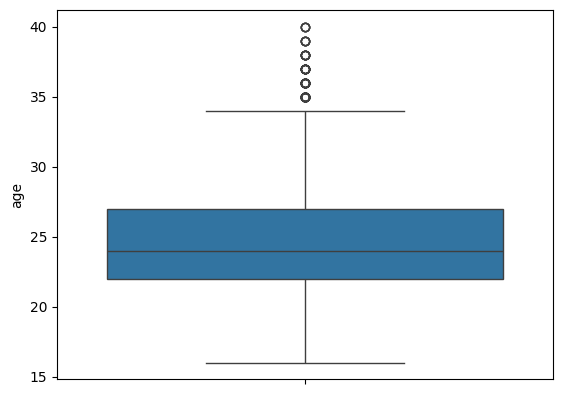

In [18]:
sns.boxplot(y=df['age'])
plt.show()

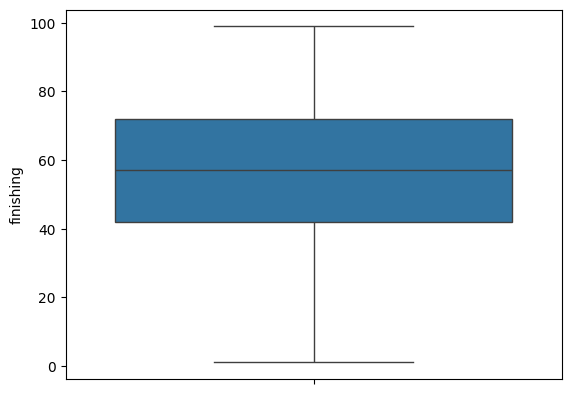

In [19]:
sns.boxplot(y=df['finishing'])
plt.show()

99.0
18.0


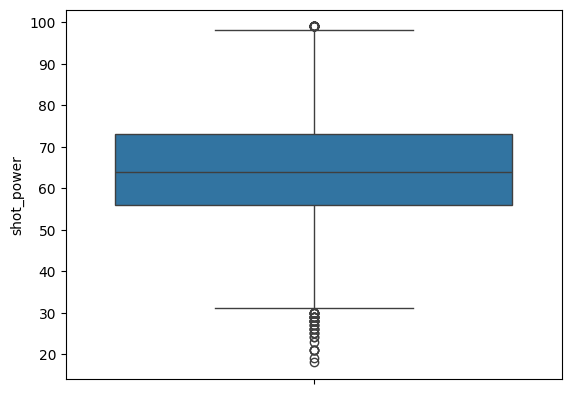

In [20]:
sns.boxplot(y=df['shot_power'])
print(df['shot_power'].max())
print(df['shot_power'].min())
plt.show()

99.0
15.0


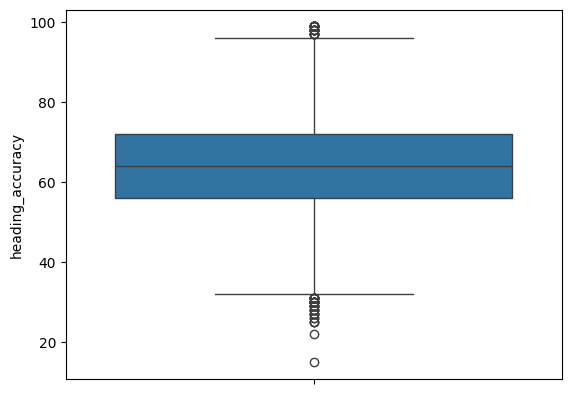

In [21]:
sns.boxplot(y=df['heading_accuracy'])
print(df['heading_accuracy'].max())
print(df['heading_accuracy'].min())
plt.show()


Column: crossing
Max: 99.0
Min: 1.0


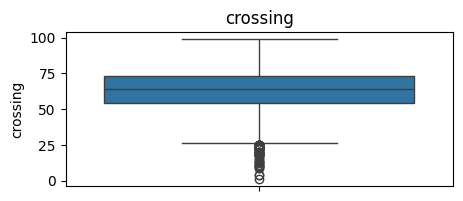


Column: short_passing
Max: 99.0
Min: 18.0


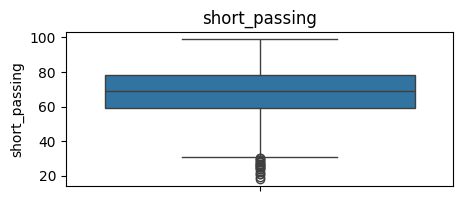


Column: long_passing
Max: 99.0
Min: 21.0


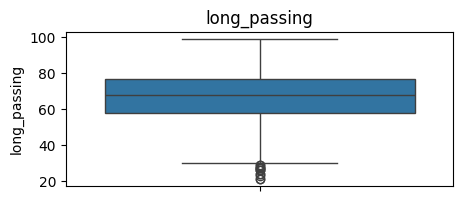


Column: through_ball
Max: 99.0
Min: 14.0


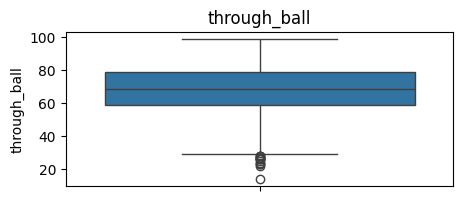


Column: dribbling
Max: 99.0
Min: 1.0


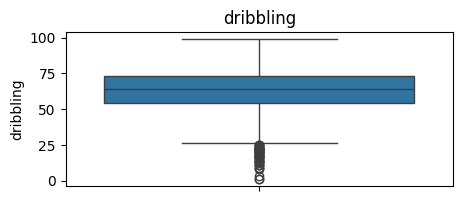


Column: ball_control
Max: 99.0
Min: 19.0


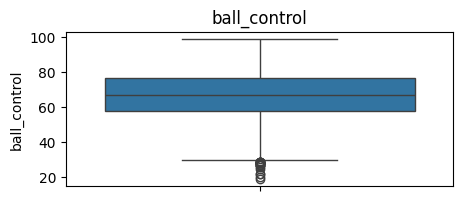


Column: standing_tackle
Max: 99.0
Min: 1.0


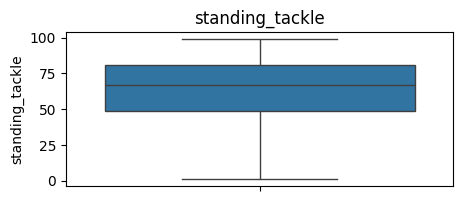


Column: sliding_tackle
Max: 99.0
Min: 1.0


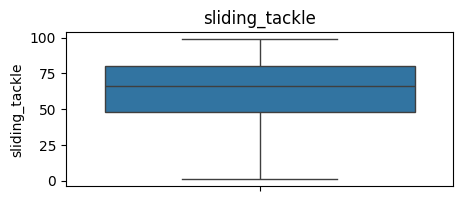


Column: interceptions
Max: 99.0
Min: 21.0


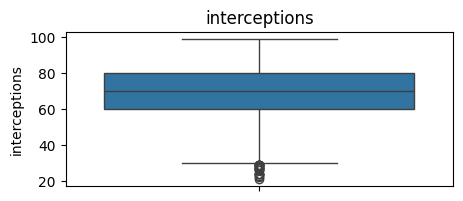


Column: defensive_awareness
Max: 99.0
Min: 13.0


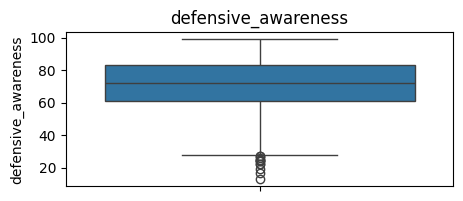


Column: acceleration
Max: 99.0
Min: 17.0


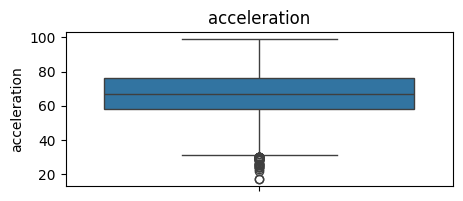


Column: speed
Max: 999.0
Min: -50.0


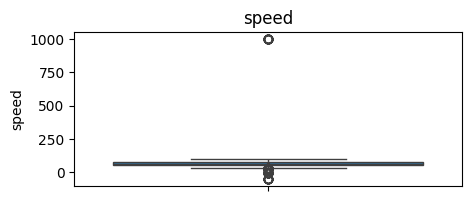


Column: agility
Max: 99.0
Min: 19.0


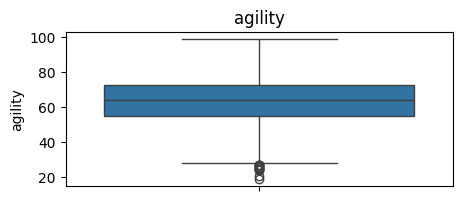


Column: balance
Max: 99.0
Min: 21.0


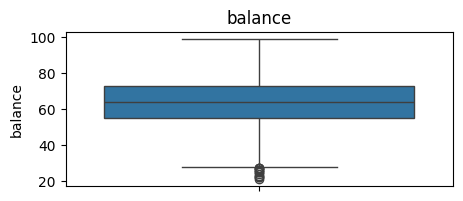


Column: jumping
Max: 99.0
Min: 15.0


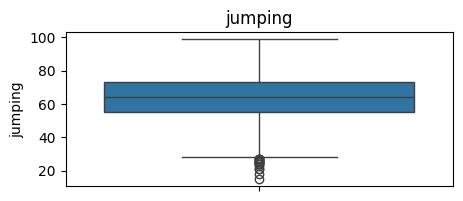


Column: strength
Max: 99.0
Min: 20.0


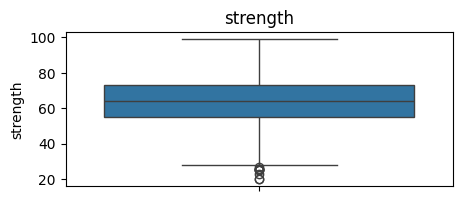


Column: stamina
Max: 999.0
Min: -50.0


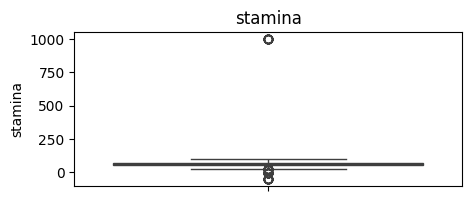


Column: offensive_awareness
Max: 99.0
Min: 19.0


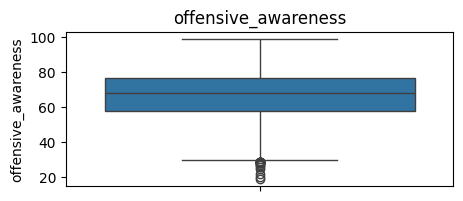


Column: composure
Max: 99.0
Min: 20.0


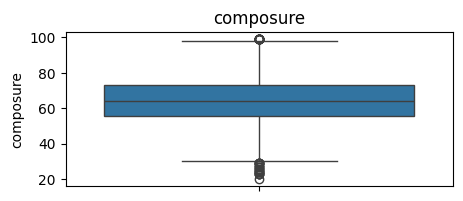


Column: reactions
Max: 99.0
Min: 19.0


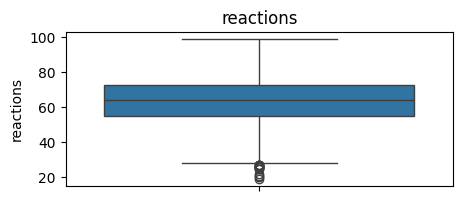


Column: gk_diving
Max: 999.0
Min: -50.0


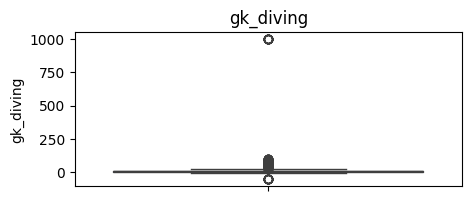


Column: gk_handling
Max: 999.0
Min: -50.0


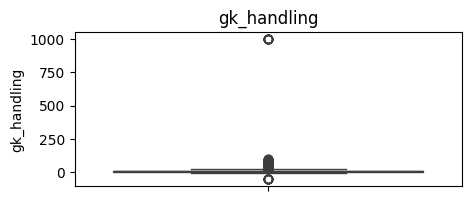


Column: gk_kicking
Max: 999.0
Min: -50.0


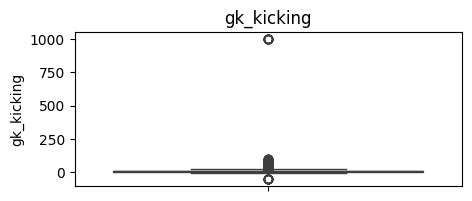


Column: gk_reflexes
Max: 999.0
Min: -50.0


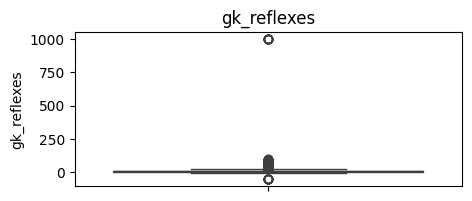


Column: gk_positioning
Max: 999.0
Min: -50.0


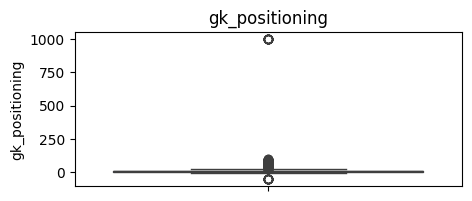

In [22]:
for col in df.loc[:, 'crossing':'gk_positioning'].columns:
    plt.figure(figsize=(5, 2))

    sns.boxplot(y=df[col])

    print(f"\nColumn: {col}")
    print("Max:", df[col].max())
    print("Min:", df[col].min())

    plt.title(col)
    plt.show()

In [23]:
df['speed'].unique()

array([ 67.,  55.,  59.,  50.,  58.,  64.,  80.,  71.,  68.,  60.,  54.,
        73.,  83.,  88.,  81.,  51.,  77.,  41.,  43.,  98.,  63.,  75.,
        61.,  69.,  47.,  74.,  66.,  38.,  94., 999.,  76.,  91.,  49.,
        48.,  99.,  45.,  93.,  96.,  62.,  53.,  82.,  46.,  65.,  79.,
        86.,  42.,  57.,  56.,  84.,  89.,  -1., -50.,  92.,  78.,  72.,
        44.,  90.,  35.,  85.,  33.,  31.,  32.,  52.,  37.,  95.,  39.,
        87.,  30.,  70.,  27.,  36.,  28.,  40.,  15.,  34.,  19.,  26.,
        24.,  97.,  23.,  21.,  25.,  18.])

In [24]:
count = ((df['speed'] < 1) | (df['speed'] > 99)).sum()
print(count)

78


In [25]:
df.loc[(df['speed'] < 1) | (df['speed'] > 99), 'speed'] = np.nan
df['speed'] = df['speed'].fillna(df['speed'].median())
df

/tmp/ipykernel_799/1291657236.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['speed'] = df['speed'].fillna(df['speed'].median())


,age,position,finishing,shot_power,heading_accuracy,crossing,short_passing,long_passing,through_ball,dribbling,...,stamina,offensive_awareness,composure,reactions,gk_diving,gk_handling,gk_kicking,gk_reflexes,gk_positioning,overall_rating
0,29.0,CM,57.0,91.0,64.0,75.0,99.0,86.0,92.0,79.0,...,91.0,68.0,75.0,87.0,13.0,8.0,15.0,16.0,4.0,91
1,30.0,RB,57.0,49.0,64.0,63.0,36.0,49.0,69.0,36.0,...,42.0,61.0,57.0,39.0,2.0,8.0,6.0,7.0,4.0,59
2,16.0,CB,36.0,54.0,65.0,55.0,58.0,57.0,65.0,53.0,...,73.0,66.0,48.0,59.0,11.0,10.0,7.0,12.0,9.0,64
3,29.0,LM,57.0,72.0,59.0,72.0,64.0,77.0,63.0,70.0,...,49.0,68.0,62.0,64.0,4.0,8.0,3.0,11.0,7.0,61
4,21.0,LW,70.0,60.0,59.0,59.0,66.0,53.0,69.0,60.0,...,39.0,82.0,61.0,43.0,4.0,2.0,10.0,4.0,3.0,60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,21.0,CAM,54.0,80.0,74.0,61.0,72.0,71.0,73.0,53.0,...,52.0,62.0,52.0,55.0,16.0,14.0,13.0,16.0,11.0,71
7996,32.0,RW,66.0,63.0,59.0,53.0,72.0,57.0,68.0,55.0,...,56.0,68.0,54.0,44.0,9.0,12.0,13.0,11.0,15.0,59
7997,35.0,CDM,39.0,75.0,84.0,82.0,78.0,81.0,68.0,77.0,...,76.0,67.0,79.0,86.0,14.0,3.0,9.0,1.0,10.0,91
7998,25.0,CB,13.0,50.0,36.0,54.0,43.0,39.0,42.0,58.0,...,58.0,38.0,45.0,57.0,7.0,14.0,13.0,11.0,3.0,54


In [26]:
count = ((df['stamina'] < 1) | (df['stamina'] > 99)).sum()
print(count)

63


In [27]:
df.loc[(df['stamina'] < 1) | (df['stamina'] > 99), 'stamina'] = np.nan
df['stamina'] = df['stamina'].fillna(df['stamina'].median())
df

/tmp/ipykernel_799/939081638.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['stamina'] = df['stamina'].fillna(df['stamina'].median())


,age,position,finishing,shot_power,heading_accuracy,crossing,short_passing,long_passing,through_ball,dribbling,...,stamina,offensive_awareness,composure,reactions,gk_diving,gk_handling,gk_kicking,gk_reflexes,gk_positioning,overall_rating
0,29.0,CM,57.0,91.0,64.0,75.0,99.0,86.0,92.0,79.0,...,91.0,68.0,75.0,87.0,13.0,8.0,15.0,16.0,4.0,91
1,30.0,RB,57.0,49.0,64.0,63.0,36.0,49.0,69.0,36.0,...,42.0,61.0,57.0,39.0,2.0,8.0,6.0,7.0,4.0,59
2,16.0,CB,36.0,54.0,65.0,55.0,58.0,57.0,65.0,53.0,...,73.0,66.0,48.0,59.0,11.0,10.0,7.0,12.0,9.0,64
3,29.0,LM,57.0,72.0,59.0,72.0,64.0,77.0,63.0,70.0,...,49.0,68.0,62.0,64.0,4.0,8.0,3.0,11.0,7.0,61
4,21.0,LW,70.0,60.0,59.0,59.0,66.0,53.0,69.0,60.0,...,39.0,82.0,61.0,43.0,4.0,2.0,10.0,4.0,3.0,60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,21.0,CAM,54.0,80.0,74.0,61.0,72.0,71.0,73.0,53.0,...,52.0,62.0,52.0,55.0,16.0,14.0,13.0,16.0,11.0,71
7996,32.0,RW,66.0,63.0,59.0,53.0,72.0,57.0,68.0,55.0,...,56.0,68.0,54.0,44.0,9.0,12.0,13.0,11.0,15.0,59
7997,35.0,CDM,39.0,75.0,84.0,82.0,78.0,81.0,68.0,77.0,...,76.0,67.0,79.0,86.0,14.0,3.0,9.0,1.0,10.0,91
7998,25.0,CB,13.0,50.0,36.0,54.0,43.0,39.0,42.0,58.0,...,58.0,38.0,45.0,57.0,7.0,14.0,13.0,11.0,3.0,54


In [28]:
df.loc[(df['gk_diving'] < 1) | (df['gk_diving'] > 99), 'gk_diving'] = np.nan
df['gk_diving'] = df['gk_diving'].fillna(df['gk_diving'].median())

df.loc[(df['gk_handling'] < 1) | (df['gk_handling'] > 99), 'gk_handling'] = np.nan
df['gk_handling'] = df['gk_handling'].fillna(df['gk_handling'].median())

df.loc[(df['gk_kicking'] < 1) | (df['gk_kicking'] > 99), 'gk_kicking'] = np.nan
df['gk_kicking'] = df['gk_kicking'].fillna(df['gk_kicking'].median())

df.loc[(df['gk_reflexes'] < 1) | (df['gk_reflexes'] > 99), 'gk_reflexes'] = np.nan
df['gk_reflexes'] = df['gk_reflexes'].fillna(df['gk_reflexes'].median())

df.loc[(df['gk_positioning'] < 1) | (df['gk_positioning'] > 99), 'gk_positioning'] = np.nan
df['gk_positioning'] = df['gk_positioning'].fillna(df['gk_positioning'].median())

/tmp/ipykernel_799/4103585594.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['gk_diving'] = df['gk_diving'].fillna(df['gk_diving'].median())
/tmp/ipykernel_799/4103585594.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['gk_handling'] = df['gk_handling'].fillna(df['gk_handling'].median())
/tmp/ipykernel_799/4103585594.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the 

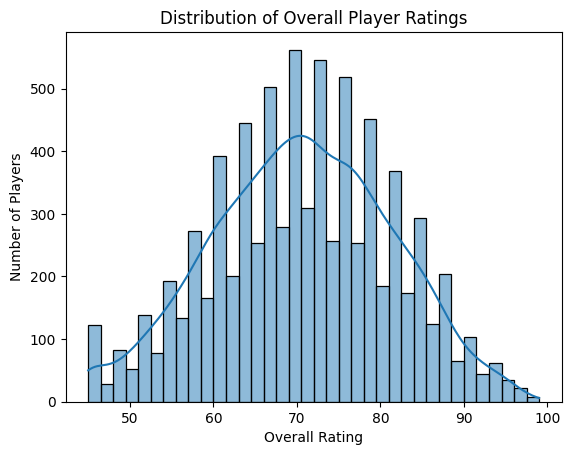

In [29]:
sns.histplot(df['overall_rating'], kde=True)
plt.title('Distribution of Overall Player Ratings')
plt.xlabel('Overall Rating')
plt.ylabel('Number of Players')
plt.show()

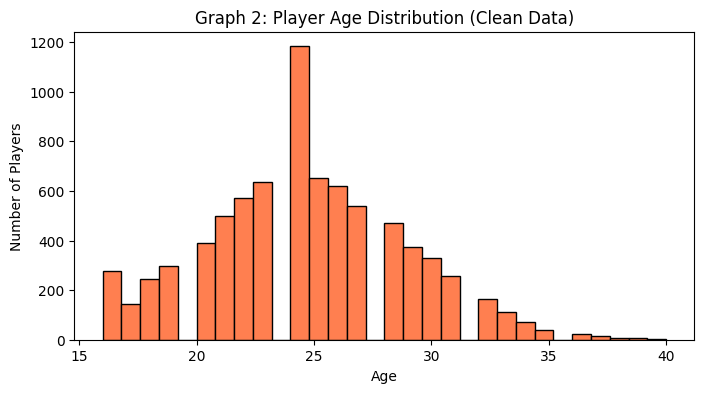

In [30]:
plt.figure(figsize=(8, 4))
plt.hist(df["age"].dropna(), bins=30, color="coral", edgecolor="black")
plt.title("Graph 2: Player Age Distribution (Clean Data)")
plt.xlabel("Age")
plt.ylabel("Number of Players")
plt.show()

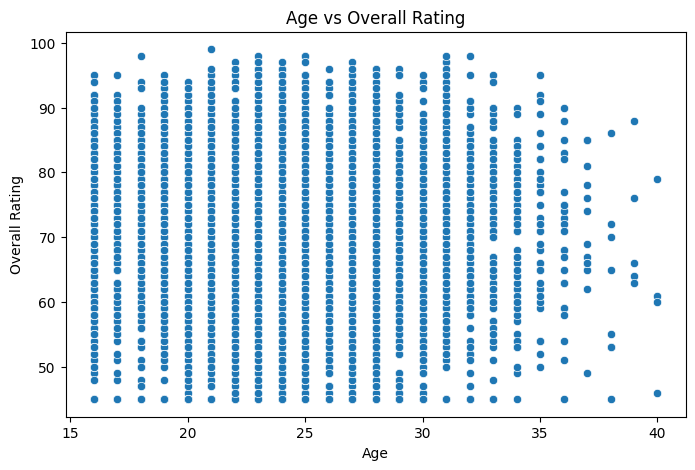

In [31]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='age',
    y='overall_rating'
)

plt.title('Age vs Overall Rating')
plt.xlabel('Age')
plt.ylabel('Overall Rating')

plt.show()

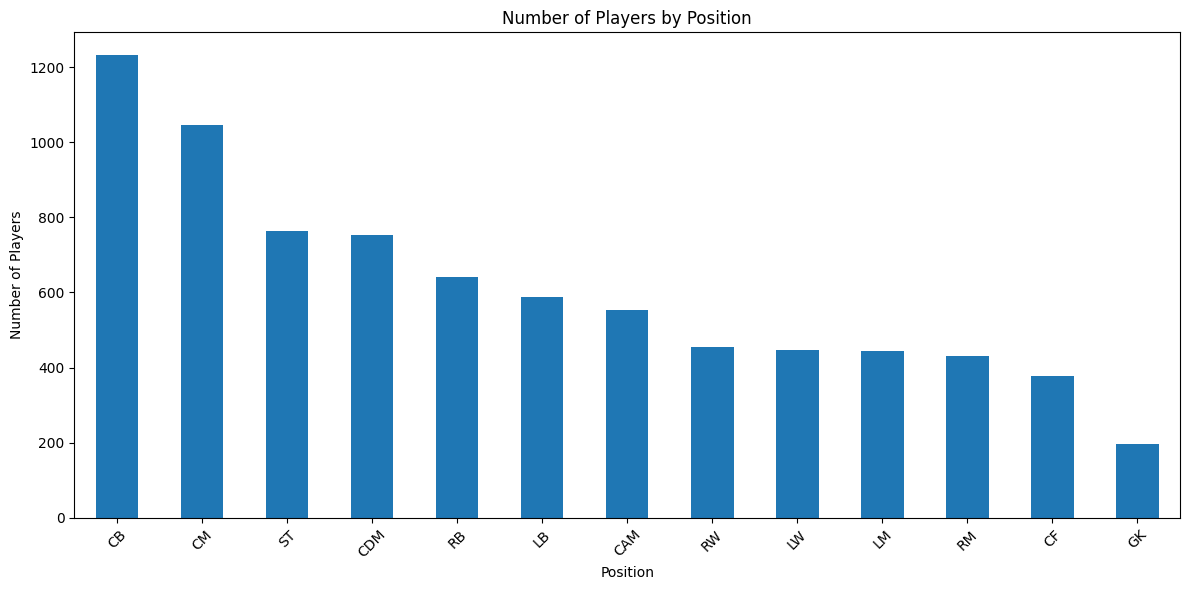

In [32]:
position_counts = df['position'].value_counts()

# Plot
plt.figure(figsize=(12,6))
position_counts.plot(kind='bar')

plt.title('Number of Players by Position')
plt.xlabel('Position')
plt.ylabel('Number of Players')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [33]:
df

,age,position,finishing,shot_power,heading_accuracy,crossing,short_passing,long_passing,through_ball,dribbling,...,stamina,offensive_awareness,composure,reactions,gk_diving,gk_handling,gk_kicking,gk_reflexes,gk_positioning,overall_rating
0,29.0,CM,57.0,91.0,64.0,75.0,99.0,86.0,92.0,79.0,...,91.0,68.0,75.0,87.0,13.0,8.0,15.0,16.0,4.0,91
1,30.0,RB,57.0,49.0,64.0,63.0,36.0,49.0,69.0,36.0,...,42.0,61.0,57.0,39.0,2.0,8.0,6.0,7.0,4.0,59
2,16.0,CB,36.0,54.0,65.0,55.0,58.0,57.0,65.0,53.0,...,73.0,66.0,48.0,59.0,11.0,10.0,7.0,12.0,9.0,64
3,29.0,LM,57.0,72.0,59.0,72.0,64.0,77.0,63.0,70.0,...,49.0,68.0,62.0,64.0,4.0,8.0,3.0,11.0,7.0,61
4,21.0,LW,70.0,60.0,59.0,59.0,66.0,53.0,69.0,60.0,...,39.0,82.0,61.0,43.0,4.0,2.0,10.0,4.0,3.0,60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,21.0,CAM,54.0,80.0,74.0,61.0,72.0,71.0,73.0,53.0,...,52.0,62.0,52.0,55.0,16.0,14.0,13.0,16.0,11.0,71
7996,32.0,RW,66.0,63.0,59.0,53.0,72.0,57.0,68.0,55.0,...,56.0,68.0,54.0,44.0,9.0,12.0,13.0,11.0,15.0,59
7997,35.0,CDM,39.0,75.0,84.0,82.0,78.0,81.0,68.0,77.0,...,76.0,67.0,79.0,86.0,14.0,3.0,9.0,1.0,10.0,91
7998,25.0,CB,13.0,50.0,36.0,54.0,43.0,39.0,42.0,58.0,...,58.0,38.0,45.0,57.0,7.0,14.0,13.0,11.0,3.0,54


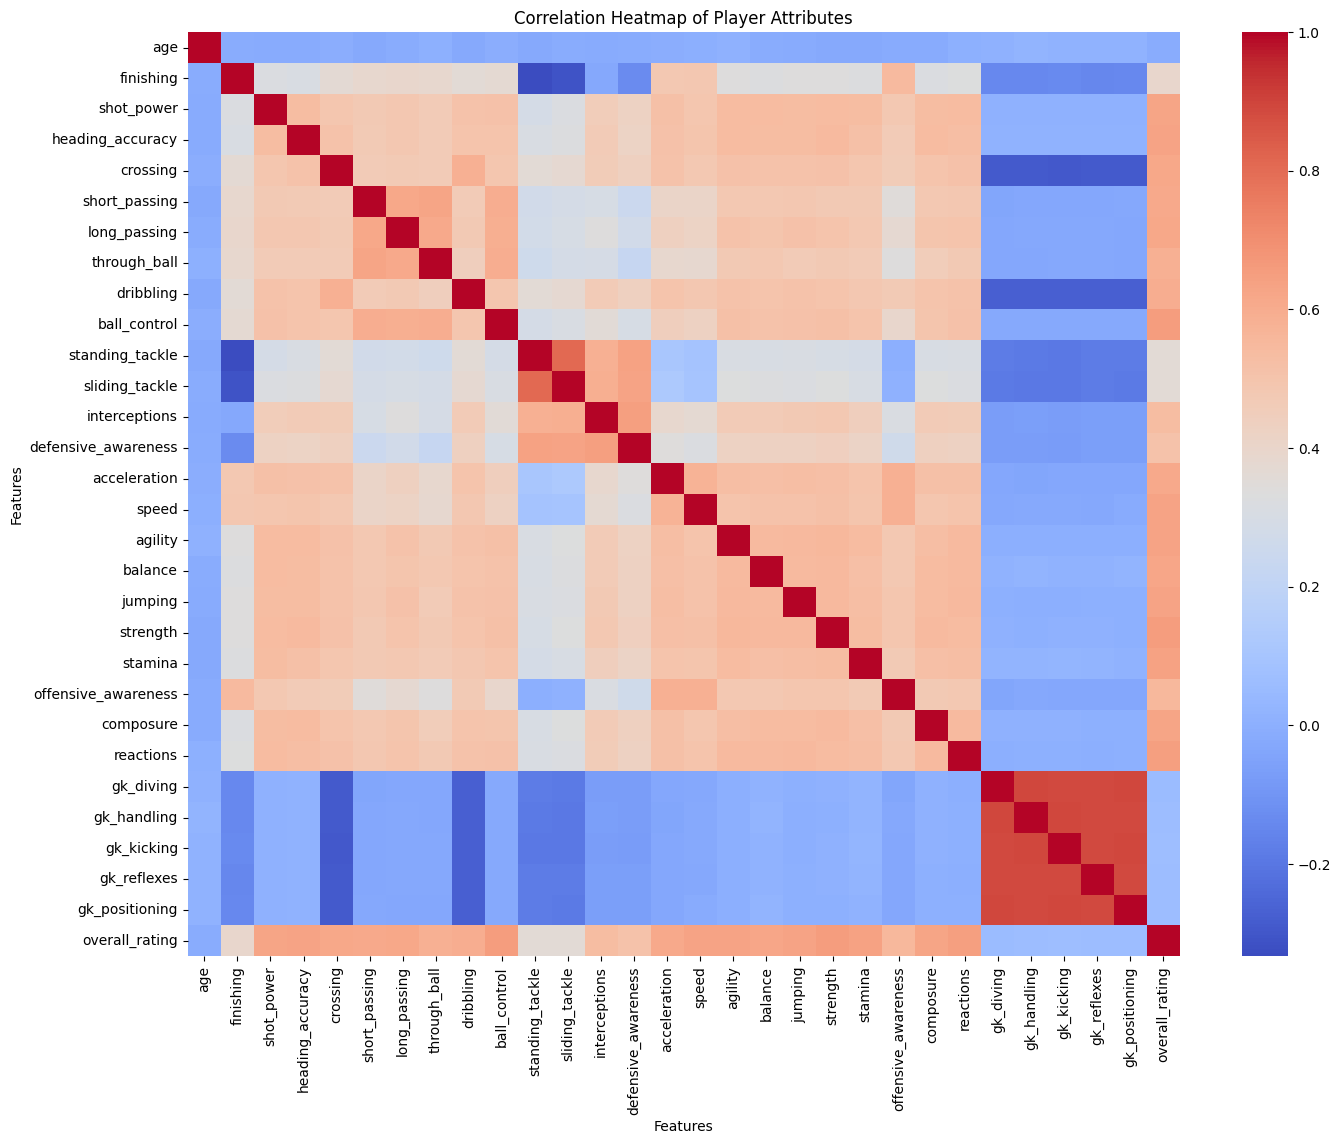

In [34]:
plt.figure(figsize=(16,12))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap='coolwarm'
)

plt.title('Correlation Heatmap of Player Attributes')
plt.xlabel('Features')
plt.ylabel('Features')

plt.show()

In [35]:

x=df.drop(columns='overall_rating')
x

,age,position,finishing,shot_power,heading_accuracy,crossing,short_passing,long_passing,through_ball,dribbling,...,strength,stamina,offensive_awareness,composure,reactions,gk_diving,gk_handling,gk_kicking,gk_reflexes,gk_positioning
0,29.0,CM,57.0,91.0,64.0,75.0,99.0,86.0,92.0,79.0,...,89.0,91.0,68.0,75.0,87.0,13.0,8.0,15.0,16.0,4.0
1,30.0,RB,57.0,49.0,64.0,63.0,36.0,49.0,69.0,36.0,...,55.0,42.0,61.0,57.0,39.0,2.0,8.0,6.0,7.0,4.0
2,16.0,CB,36.0,54.0,65.0,55.0,58.0,57.0,65.0,53.0,...,59.0,73.0,66.0,48.0,59.0,11.0,10.0,7.0,12.0,9.0
3,29.0,LM,57.0,72.0,59.0,72.0,64.0,77.0,63.0,70.0,...,64.0,49.0,68.0,62.0,64.0,4.0,8.0,3.0,11.0,7.0
4,21.0,LW,70.0,60.0,59.0,59.0,66.0,53.0,69.0,60.0,...,42.0,39.0,82.0,61.0,43.0,4.0,2.0,10.0,4.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,21.0,CAM,54.0,80.0,74.0,61.0,72.0,71.0,73.0,53.0,...,74.0,52.0,62.0,52.0,55.0,16.0,14.0,13.0,16.0,11.0
7996,32.0,RW,66.0,63.0,59.0,53.0,72.0,57.0,68.0,55.0,...,61.0,56.0,68.0,54.0,44.0,9.0,12.0,13.0,11.0,15.0
7997,35.0,CDM,39.0,75.0,84.0,82.0,78.0,81.0,68.0,77.0,...,83.0,76.0,67.0,79.0,86.0,14.0,3.0,9.0,1.0,10.0
7998,25.0,CB,13.0,50.0,36.0,54.0,43.0,39.0,42.0,58.0,...,35.0,58.0,38.0,45.0,57.0,7.0,14.0,13.0,11.0,3.0


In [36]:
df

,age,position,finishing,shot_power,heading_accuracy,crossing,short_passing,long_passing,through_ball,dribbling,...,stamina,offensive_awareness,composure,reactions,gk_diving,gk_handling,gk_kicking,gk_reflexes,gk_positioning,overall_rating
0,29.0,CM,57.0,91.0,64.0,75.0,99.0,86.0,92.0,79.0,...,91.0,68.0,75.0,87.0,13.0,8.0,15.0,16.0,4.0,91
1,30.0,RB,57.0,49.0,64.0,63.0,36.0,49.0,69.0,36.0,...,42.0,61.0,57.0,39.0,2.0,8.0,6.0,7.0,4.0,59
2,16.0,CB,36.0,54.0,65.0,55.0,58.0,57.0,65.0,53.0,...,73.0,66.0,48.0,59.0,11.0,10.0,7.0,12.0,9.0,64
3,29.0,LM,57.0,72.0,59.0,72.0,64.0,77.0,63.0,70.0,...,49.0,68.0,62.0,64.0,4.0,8.0,3.0,11.0,7.0,61
4,21.0,LW,70.0,60.0,59.0,59.0,66.0,53.0,69.0,60.0,...,39.0,82.0,61.0,43.0,4.0,2.0,10.0,4.0,3.0,60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,21.0,CAM,54.0,80.0,74.0,61.0,72.0,71.0,73.0,53.0,...,52.0,62.0,52.0,55.0,16.0,14.0,13.0,16.0,11.0,71
7996,32.0,RW,66.0,63.0,59.0,53.0,72.0,57.0,68.0,55.0,...,56.0,68.0,54.0,44.0,9.0,12.0,13.0,11.0,15.0,59
7997,35.0,CDM,39.0,75.0,84.0,82.0,78.0,81.0,68.0,77.0,...,76.0,67.0,79.0,86.0,14.0,3.0,9.0,1.0,10.0,91
7998,25.0,CB,13.0,50.0,36.0,54.0,43.0,39.0,42.0,58.0,...,58.0,38.0,45.0,57.0,7.0,14.0,13.0,11.0,3.0,54


In [37]:
df = pd.get_dummies(
    df,
    columns=['position']
)

In [38]:
x=df.drop(columns='overall_rating')
x

,age,finishing,shot_power,heading_accuracy,crossing,short_passing,long_passing,through_ball,dribbling,ball_control,...,position_CF,position_CM,position_GK,position_LB,position_LM,position_LW,position_RB,position_RM,position_RW,position_ST
0,29.0,57.0,91.0,64.0,75.0,99.0,86.0,92.0,79.0,89.0,...,False,True,False,False,False,False,False,False,False,False
1,30.0,57.0,49.0,64.0,63.0,36.0,49.0,69.0,36.0,39.0,...,False,False,False,False,False,False,True,False,False,False
2,16.0,36.0,54.0,65.0,55.0,58.0,57.0,65.0,53.0,46.0,...,False,False,False,False,False,False,False,False,False,False
3,29.0,57.0,72.0,59.0,72.0,64.0,77.0,63.0,70.0,62.0,...,False,False,False,False,True,False,False,False,False,False
4,21.0,70.0,60.0,59.0,59.0,66.0,53.0,69.0,60.0,65.0,...,False,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,21.0,54.0,80.0,74.0,61.0,72.0,71.0,73.0,53.0,74.0,...,False,False,False,False,False,False,False,False,False,False
7996,32.0,66.0,63.0,59.0,53.0,72.0,57.0,68.0,55.0,69.0,...,False,False,False,False,False,False,False,False,True,False
7997,35.0,39.0,75.0,84.0,82.0,78.0,81.0,68.0,77.0,87.0,...,False,False,False,False,False,False,False,False,False,False
7998,25.0,13.0,50.0,36.0,54.0,43.0,39.0,42.0,58.0,61.0,...,False,False,False,False,False,False,False,False,False,False


In [39]:
y=df['overall_rating']
y

,overall_rating
0,91
1,59
2,64
3,61
4,60
...,...
7995,71
7996,59
7997,91
7998,54


In [40]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.30,random_state=42)

In [42]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error


R2 Score: 0.8453266245740647
MAE: 3.2295961125189065
RMSE: 4.205048261017841
MAPE: 0.04690170350277281


In [45]:
# random forest
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)



In [46]:
y_train_pred_rf = rf.predict(x_train)
print("Training R2:", r2_score(y_train, y_train_pred_rf))

Training R2: 0.9754708906686882


In [47]:
print("R2 Score:", r2_score(y_test, y_pred_rf))
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("MAPE:", mean_absolute_percentage_error(y_test, y_pred_rf))

R2 Score: 0.815216008207009
MAE: 3.6970521446593776
RMSE: 4.596162502721711
MAPE: 0.05423968432604579


In [48]:
joblib.dump(rf, "player_rating_model.pkl")

['player_rating_model.pkl']

In [49]:
corr = df.corr(numeric_only=True)["overall_rating"].sort_values(ascending=False)
print(corr)

overall_rating         1.000000
strength               0.651609
ball_control           0.651467
reactions              0.649646
stamina                0.638051
jumping                0.634221
agility                0.633841
heading_accuracy       0.631729
speed                  0.630521
composure              0.628043
shot_power             0.625475
balance                0.624560
crossing               0.619723
long_passing           0.616088
acceleration           0.613636
short_passing          0.611893
dribbling              0.598942
through_ball           0.585959
offensive_awareness    0.555687
interceptions          0.531961
defensive_awareness    0.505903
finishing              0.393526
standing_tackle        0.364216
sliding_tackle         0.363514
position_CM            0.146390
position_CDM           0.136162
position_CAM           0.101519
gk_kicking             0.062697
gk_positioning         0.061457
gk_reflexes            0.061077
gk_handling            0.060596
gk_divin